In [3]:
import numpy as np
import matplotlib.pyplot as plt

R = 8.3145 
T = 283.15 #K

In [4]:
# Idea: haz una implementacion generalizada de UNIFAC, pero luego. Y seria chevere que el codigo pueda determinar los grupos funcionales.
# def unifac(substances):
#     #subtances array


In [12]:
#combinatorial
v1one = 2
v1two = 4
v2one = 1
v2five = 1

r1 = v1two * (0.67444) + v1one * (0.9011) #volumen de la molecula 1
q1 = v1two * (0.540) + v1one * (0.848) #area de la molecula 1
q2 = v2one * (0.848 + 1.2) #area de la molecula 2
r2 = v2one * (0.9011 + 1) #volumen de la molecula 1
z = 10

phi1 = lambda x1: (x1*r1)/(x1*r1 + (1-x1)*r2) #volumen molecula 1
phi2 = lambda x1: ((1-x1)*r2)/(x1*r1 + (1-x1)*r2) #volumen molecula 2
theta1 = lambda x1: (x1*q1)/(x1*q1 + (1-x1)*q2) #area superficial molecula 1
theta2 = lambda x1: ((1-x1)*q2)/(x1*q1 + (1-x1)*q2) #area superficial molecula 2
l1 = (z/2)*(r1-q1)-(r1-1) #no significado fisico
l2 = (z/2)*(r2-q2)-(r2-1) #no significado fisico
lnGammaC1 = lambda x1, phi1var, theta1var: np.log(phi1var/x1) + (z/2)*(q1*np.log(theta1var/phi1var))+l1-(phi1var/x1)*(x1*l1 + (1-x1)*l2) #lngamma hexamo combinatorial
lnGammaC2 = lambda x1, phi2var, theta2var: np.log(phi2var/(1-x1)) + (z/2)*(q2*np.log(theta2var/phi2var))+l2-(phi2var/(1-x1))*(x1*l1 + (1-x1)*l2) #lngamma metanol combinatorial

In [16]:
def residual(x1):     
#residual
    a15 = 644.6 #deltaEnergia de interaccion entre grupo 1 y grupo 5
    a51 = 328.2 #deltaEnergia de interaccion entre grupo 5 y grupo 1
    a11 = 0 #deltaEnergia de interaccion entre grupo 1 y grupo 1
    a55 = 0
    psi15 = np.exp(-1*a15/(R*T))
    psi51 = np.exp(-1*a51/(R*T))
    psi55 = 1
    psi11 = 1 #psi11 and psi12
    X1two = 2/3 #proporcion de CH2 en la molecula 1 (hexano)
    X1one = 1/3 #proporcion de CH3 en la molecula 1 (hexano)
    X2one = 1/2 #proporcion de CH3 en la molecula 2 (metanol)
    X2five = 1/2 #proporcion de OH en la molecula 2 (metanol)
    Qone = 0.540
    Qtwo = 0.848
    Qfive = 1.2
    theta1one = Qone * X1one / (Qone* X1one + X1two*Qtwo) #area superficial de CH3 en la molecula 1 (hexano) 
    theta1two = Qtwo * X1two / (Qone* X1one + X1two*Qtwo) #area superficial de CH2 en la molecula 1 (hexano)
    theta2one = Qone * X2one / (X2one * Qone + X2five * Qfive) #area superficial de CH3 en la molecula 2 (metanol)
    theta2five = Qfive * X2five / (X2one * Qtwo + X2five * Qfive) #area superficial de OH en la molecula 1 (metanol)
    Qone = 0.540
    Qtwo = 0.848
    Qfive = 1.2


    lnGamma1one = Qone*(1-np.log(theta1one*psi11 + theta1two*psi11)-(theta1one*psi11/(theta1one*psi11 + theta1two*psi11)) - (theta1two*psi11/(theta1one*psi11  + theta1two*psi11))) #logaritmo de coeficiente de actividad de CH3 en la molecula 1 (hexano)
    lnGamma1two = Qtwo*(1-np.log(theta1one*psi11 + theta1two*psi11)-(theta1one*psi11/(theta1one*psi11 + theta1two*psi11)) - (theta1two*psi11/(theta1one*psi11 + theta1two*psi11))) #logaritmo de coeficiente de actividad de CH2 en la molecula 1 (hexano)
    lnGamma2one = Qone*(1-np.log(theta2one*psi11 + theta2five*psi51)-(theta2one*psi11/(theta2one*psi11 + theta2five*psi51)) - (theta2five*psi15/(theta2one*psi15 + theta2five*psi55))) #logaritmo de coeficiente de actividad de CH3 en la molecula 2 (metanol)
    lnGamma2five = Qfive*(1-np.log(theta2one*psi15 + theta2five*psi55)-(theta2one*psi51/(theta2one*psi11 + theta2five*psi51)) - (theta2five*psi55/(theta2one*psi15 + theta2five*psi55))) #logaritmo de coeficiente de actividad de OH en la molecula 2 (metanol)

    Xone = lambda x1: (x1*v1one + (1-x1)*v2one)/(x1*(v1one + v1two)  + (1-x1)*(v2one + v2five)) #fraccion de CH3 en la mezcla
    Xtwo = lambda x1: (x1*v1two)/(x1*(v1one + v1two)  + (1-x1)*(v2one + v2five)) #fraccion de CH2 en la mezcla
    Xfive = lambda x1: ((1-x1)*v2five)/(x1*(v1one + v1two)  + (1-x1)*(v2one + v2five)) #fraccion de OH en la mezcla

    Xonevar = Xone(x1)
    Xtwovar = Xtwo(x1)
    Xfivevar = Xfive(x1)
    

    

    thetaOne = Qone*Xonevar/(Qone*Xonevar + Qtwo*Xtwovar + Qfive*Xfivevar)
    thetaTwo = Qtwo*Xtwovar/(Qone*Xonevar + Qtwo*Xtwovar + Qfive*Xfivevar) 
    thetaFive = Qfive*Xfivevar/(Qone*Xonevar + Qtwo*Xtwovar + Qfive*Xfivevar)

    #a todas estas faltas incluirles un elemento. Un grupo funcional, ya que ya es en la mezcla, y no en la molecula, entonces en total en la mezcla hay 3 grupos funcionales, no solo 2. 
    lnGammaOne = Qone*(1-np.log(thetaOne*psi11 + thetaTwo*psi11 + thetaFive*psi51)-(thetaOne*psi11/(thetaOne*psi11 + thetaTwo*psi11 + thetaFive*psi51)) - (thetaTwo*psi11/(thetaOne*psi11  + thetaTwo*psi11 + thetaFive*psi51))) - (thetaFive*psi15/(thetaOne*psi15 + thetaTwo*psi15 + thetaFive*psi55)) #logaritmo de coeficiente de actividad de CH3 en la mezcla
    lnGammaTwo = Qtwo*(1-np.log(thetaOne*psi11 + thetaTwo*psi11 + thetaFive*psi51)-(thetaOne*psi11/(thetaOne*psi11 + thetaTwo*psi11 + thetaFive*psi51)) - (thetaTwo*psi11/(thetaOne*psi11 + thetaTwo*psi11 + thetaFive*psi51))) - (thetaFive*psi15/(thetaOne*psi15 + thetaTwo*psi15 + thetaFive*psi55)) #logaritmo de coeficiente de actividad de CH2 en la mezcla
    lnGammaFive = Qfive*(1-np.log(thetaOne*psi15 + thetaFive*psi55 + thetaTwo*psi15)-(thetaOne*psi51/(thetaOne*psi11 + thetaFive*psi51 + thetaTwo*psi11)) - (thetaFive*psi55/(thetaOne*psi15 + thetaFive*psi55 + thetaTwo*psi15)) - (thetaTwo*psi51/(thetaOne*psi11 + thetaTwo*psi11 + thetaFive*psi51))) #logaritmo de coeficiente de actividad de OH en la mezcla


    lnGammaR1 = v1one*(lnGammaOne - lnGamma1one) + v1two*(lnGammaTwo - lnGamma1two)

    lnGammaR2 = v2one*(lnGammaOne - lnGamma2one) + v2five*(lnGammaFive - lnGamma2five)

    return lnGammaR1, lnGammaR2


GE parcial molar de 1 = RT*LN(Gamma1)
GE parcial molar de 2 = RT*LN(Gamma2) 

GE = (GE parcial molar de 1)*x1 + (GE parcial molar de 2)*x2

In [19]:
def GE(x1):
    phi1var = phi1(x1)
    phi2var = phi2(x1)
    theta1var = theta1(x1)
    theta2var = theta2(x1)
    lnGammaC1var = lnGammaC1(x1, phi1var, theta1var)
    lnGammaC2var = lnGammaC2(x1, phi2var, theta2var)

    lnGammaR1, lnGammaR2 = residual(x1)

    lnGamma1 = lnGammaR1 + lnGammaC1var
    lnGamma2 = lnGammaR2 + lnGammaC2var


    return (lnGamma1*x1 + lnGamma2*(1-x1))/(R*T)
    

Graph


C:\Users\premz\AppData\Local\Temp/ipykernel_41468/2725610897.py:19: RuntimeWarning: invalid value encountered in true_divide
  lnGammaC1 = lambda x1, phi1var, theta1var: np.log(phi1var/x1) + (z/2)*(q1*np.log(theta1var/phi1var))+l1-(phi1var/x1)*(x1*l1 + (1-x1)*l2) #lngamma hexamo combinatorial
C:\Users\premz\AppData\Local\Temp/ipykernel_41468/2725610897.py:20: RuntimeWarning: invalid value encountered in true_divide
  lnGammaC2 = lambda x1, phi2var, theta2var: np.log(phi2var/(1-x1)) + (z/2)*(q2*np.log(theta2var/phi2var))+l2-(phi2var/(1-x1))*(x1*l1 + (1-x1)*l2) #lngamma metanol combinatorial


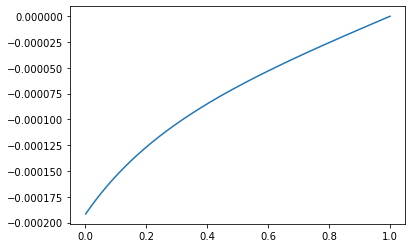

In [20]:
x = np.linspace(0,1, 1000)
y = GE(x)

plt.plot(x, y)

gemini version

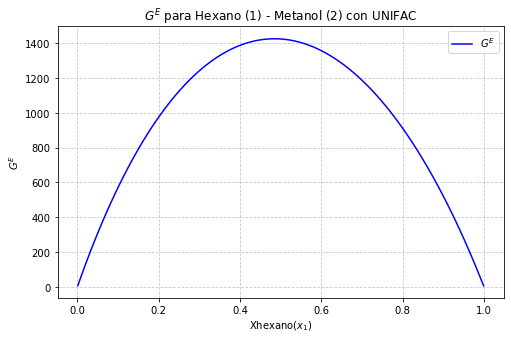

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def calculate_GE_RT(x1_array, T=283.15):
    """
    Calculates the dimensionless Excess Gibbs Energy (G^E / RT) for a 
    Hexane (1) / Methanol (2) mixture using the UNIFAC method.
    """
    # 1. Component & Group Definitions
    # Groups index: 0 = CH3, 1 = CH2, 2 = OH
    # Molecule 1 (Hexane): 2x CH3, 4x CH2, 0x OH
    # Molecule 2 (Methanol): 1x CH3, 0x CH2, 1x OH
    nu = np.array([
        [2, 4, 0],  
        [1, 0, 1]   
    ])
    
    # Volume (R_k) and Area (Q_k) parameters
    R_k = np.array([0.9011, 0.6744, 1.0000])
    Q_k = np.array([0.848, 0.540, 1.200])
    
    # Interaction parameters a_mn (in Kelvins)
    # Note: CH3 and CH2 belong to the same main group, so their interaction is 0
    a_mn = np.array([
        [0.0, 0.0, 644.6],    # CH3 interactions
        [0.0, 0.0, 644.6],    # CH2 interactions
        [328.2, 328.2, 0.0]   # OH interactions
    ])
    

    Psi = np.exp(-a_mn / T)
    z = 10.0
    

    r = np.sum(nu * R_k, axis=1)
    q = np.sum(nu * Q_k, axis=1)
    l = (z / 2) * (r - q) - (r - 1)
    
    GE_RT_list = []
    

    for x1 in x1_array:
        x = np.array([x1, 1 - x1])
        
        # Combinatorial
        Phi = (x * r) / np.sum(x * r)
        Theta = (x * q) / np.sum(x * q)
        
        ln_gamma_C = np.log(Phi / x) + (z / 2) * q * np.log(Theta / Phi) + l - (Phi / x) * np.sum(x * l)
        
        # Residual
        sum_nu_x = np.sum(x[:, np.newaxis] * nu, axis=0) # Total groups of each type
        X_m = sum_nu_x / np.sum(sum_nu_x)
        Theta_m = X_m * Q_k / np.sum(X_m * Q_k)
        
        # ln Gamma_k
        ln_Gamma_k = np.zeros(3)
        for k in range(3):
            term1 = np.sum(Theta_m * Psi[:, k])
            term2 = sum((Theta_m[m] * Psi[k, m]) / np.sum(Theta_m * Psi[:, m]) for m in range(3))
            ln_Gamma_k[k] = Q_k[k] * (1 - np.log(term1) - term2)
            
        #ln Gamma_k_i
        ln_Gamma_k_i = np.zeros((2, 3))
        for i in range(2):
            X_m_i = nu[i] / np.sum(nu[i])
            Theta_m_i = X_m_i * Q_k / np.sum(X_m_i * Q_k)
            for k in range(3):
                if nu[i, k] > 0:
                    term1 = np.sum(Theta_m_i * Psi[:, k])
                    term2 = sum((Theta_m_i[m] * Psi[k, m]) / np.sum(Theta_m_i * Psi[:, m]) for m in range(3) if Theta_m_i[m] > 0)
                    ln_Gamma_k_i[i, k] = Q_k[k] * (1 - np.log(term1) - term2)
                    
        # 4. ln_Gamma_R
        ln_gamma_R = np.zeros(2)
        for i in range(2):
            ln_gamma_R[i] = np.sum(nu[i] * (ln_Gamma_k - ln_Gamma_k_i[i]))
            
        # GE
        ln_gamma = ln_gamma_C + ln_gamma_R
        GE_RT = x[0] * ln_gamma[0] + x[1] * ln_gamma[1]
        
        GE_RT_list.append(GE_RT)
        
    return np.array(GE_RT_list)

# Generate plot
x_vals = np.linspace(0.001, 0.999, 100) # Avoid exact 0 and 1 to prevent division by zero in log
y_vals = (calculate_GE_RT(x_vals))*(R*T)

plt.figure(figsize=(8, 5))
plt.plot(x_vals, y_vals, label='$G^E$', color='blue')
plt.title('$G^E$ para Hexano (1) - Metanol (2) con UNIFAC')
plt.xlabel('Xhexano($x_1$)')
plt.ylabel('$G^E$')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()